# 28 — Sequence Layers and Language Modeling

RNN and LSTM layers transform sequences of vectors, but text begins as discrete symbols and language models must produce vocabulary scores. This notebook builds the layers connecting token IDs, recurrent hidden states, and a masked next-token loss.

## Learning objectives

- construct and use a small character vocabulary;
- implement embedding lookup and its gradient;
- accumulate gradients when token IDs repeat;
- implement a temporal affine projection;
- implement stable masked temporal softmax loss;
- align language-model inputs with next-token targets;
- trace shapes through a complete untrained language-model pipeline.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient,
    eval_numerical_gradient_array,
    relative_error,
)
from cs231n_practice.rnn_layers import rnn_forward

SEED = 42
generator = np.random.default_rng(SEED)


## 1. Vocabulary and token IDs

A model does not receive characters or words directly. A vocabulary assigns each symbol an integer ID. The ID is a lookup address, not a numerical measurement: token 5 is not semantically larger than token 2.

We reserve ID 0 for padding and assign the remaining IDs deterministically by sorting the characters. Encoding maps symbols to IDs; decoding performs the inverse mapping.

### Exercise 1 — Encode and decode a short text


In [8]:
study_text = "hello recurrent world"
characters = sorted(set(study_text))
index_to_token = ["<PAD>"] + characters
token_to_index = {token: index for index, token in enumerate(index_to_token)}

# encode every character, then reconstruct the original string.
encoded_text = np.array([token_to_index[t] for t in study_text])
decoded_text = ''.join([index_to_token[i] for i in encoded_text])

assert encoded_text.shape == (len(study_text),)
assert np.issubdtype(encoded_text.dtype, np.integer)
assert decoded_text == study_text
print("Vocabulary size:", len(index_to_token))
print("First token IDs:", encoded_text[:8])


Vocabulary size: 13
First token IDs: [5 4 6 6 8 1 9 4]


In [9]:
decoded_text

'hello recurrent world'

## 2. Embedding lookup

An embedding matrix $W_{embed}\in\mathbb{R}^{V\times D}$ stores one learned vector of length $D$ for each of $V$ vocabulary items. Integer indexing performs the forward pass:

$$
X=W_{embed}[\text{token IDs}].
$$

For token IDs with shape $(N,T)$, the output has shape $(N,T,D)$. There is no gradient with respect to the integer IDs: they are discrete row addresses, not trainable continuous values. The embedding matrix itself is trainable, so backpropagation must calculate how the loss changes with respect to each of its rows.

The upstream gradient has the same shape as the embedding output:

$$
dout_{n,t}=\frac{\partial L}{\partial X_{n,t}}\in\mathbb{R}^{D}.
$$

It tells us how changing the embedding vector selected at position $(n,t)$ would change the final loss. Since the forward operation is simply

$$
X_{n,t}=W_{embed}[\text{token\_ids}_{n,t}],
$$

the complete vector $dout_{n,t}$ is sent directly to that selected row. The local derivative is effectively $1$ for the selected row and $0$ for every other row; there is no multiplication or activation derivative to compute. In code, one occurrence therefore contributes:

```python
dembedding[token_ids[n, t]] += dout[n, t]
```

The same token can appear repeatedly, and every occurrence used the same embedding row. Therefore, all gradient contributions for that token must be added into the same row. For example, if token `1` appears three times and every upstream gradient is a vector of ones, row `dembedding[1]` becomes a vector of threes. Rows belonging to tokens that were not used remain zero.

### Exercise 2 — Implement embedding forward and backward


In [13]:
def embedding_forward(token_ids, embedding_matrix):
    """Look up one embedding vector for every integer token ID."""
    # index the matrix and cache what backward needs.
    embedded = embedding_matrix[token_ids]
    vocabulary_size = embedding_matrix.shape[0]
    cache = (token_ids, vocabulary_size)
    return embedded, cache


def embedding_backward(dout, cache):
    """Accumulate embedding gradients for all token occurrences."""
    token_ids, vocabulary_size = cache
    embedding_dim = dout.shape[-1]
    dembedding = np.zeros((vocabulary_size, embedding_dim), dtype=dout.dtype)
    # Visit each token occurrence separately.
    # If a token ID is repeated, its row is visited repeatedly, so the
    # corresponding gradient contributions are added together.
    num_examples, num_steps = token_ids.shape
    for n in range(num_examples):
        for t in range(num_steps):
            token_id = token_ids[n, t]
            dembedding[token_id] += dout[n, t]
    return dembedding

example_token_ids = np.array([[1, 2, 1], [0, 2, 1]])
example_embeddings = generator.normal(size=(4, 3))
embedded, embedding_cache = embedding_forward(
    example_token_ids, example_embeddings
)
assert embedded.shape == (2, 3, 3)
np.testing.assert_array_equal(embedded[0, 0], example_embeddings[1])

embedding_upstream = np.ones_like(embedded)
dembedding = embedding_backward(embedding_upstream, embedding_cache)
np.testing.assert_allclose(dembedding[0], 1.0)
np.testing.assert_allclose(dembedding[1], 3.0)
np.testing.assert_allclose(dembedding[2], 2.0)
np.testing.assert_allclose(dembedding[3], 0.0)


## 3. Why ordinary indexed assignment is insufficient

An assignment such as dembedding[token_ids] = dout can overwrite earlier contributions when an ID occurs more than once. The nested loop above makes the required accumulation explicit: every occurrence adds its gradient to the row for that token. Its compact NumPy equivalent is np.add.at(dembedding, token_ids, dout), which performs an unbuffered addition for every indexed occurrence.

### Exercise 3 — Numerically check the embedding matrix gradient

Only the embedding matrix is continuous and can be perturbed. Token IDs remain fixed integers.


In [14]:
numerical_dembedding = eval_numerical_gradient_array(
    lambda matrix: embedding_forward(example_token_ids, matrix)[0],
    example_embeddings,
    embedding_upstream,
)
embedding_error = relative_error(dembedding, numerical_dembedding)
print(f"embedding gradient error: {embedding_error:.3e}")
assert embedding_error < 1e-8


embedding gradient error: 2.276e-12


## 4. Temporal affine projection

A recurrent layer returns hidden states with shape $(N,T,H)$. Each length-$H$ hidden vector summarizes what the recurrent network knows at that position, but its coordinates are internal features rather than scores for particular vocabulary tokens. To predict one of $V$ tokens, we must convert every hidden vector into $V$ vocabulary scores.

We do this by applying the same affine transformation at every time step:

$$
S_{n,t,:}=H_{n,t,:}W+b.
$$

Here, $W$ has shape $(H,V)$ and $b$ has shape $(V,)$. Therefore, each hidden vector of shape $(H,)$ becomes a score vector of shape $(V,)$, and the complete score tensor has shape $(N,T,V)$:

$$
(N,T,H)\longrightarrow(N,T,V).
$$

For example, `scores[n, t, v]` is the model's score for vocabulary token $v$ in sequence $n$ at time $t$. Softmax will later convert these scores into next-token probabilities. The same $W$ and $b$ are shared across all time steps because a token must have the same output meaning regardless of its position. The recurrent layer has already handled the flow of information through time; this projection processes each time step independently and does not mix time steps.

For efficient computation, reshape $(N,T,H)$ into $(NT,H)$ and treat all positions like one large batch. Ordinary affine-layer equations then apply:

$$
S_{flat}=H_{flat}W+b.
$$

The forward result is reshaped back to $(N,T,V)$. During backward propagation, flattening again lets contributions from every sequence and time step accumulate into the shared $dW$ and $db$; only $dX$ is reshaped back to $(N,T,H)$.

### Exercise 4 — Implement temporal affine forward and backward


In [20]:
def temporal_affine_forward(x, weights, bias):
    """Apply one shared affine projection at every time step."""
    # Treat all N * T positions as one large batch of H-dimensional vectors.
    N, T, H = x.shape
    V = weights.shape[1]
    # # x reshape implementation
    # x_flat = x.reshape(N * T, H)
    # scores = (x_flat @ weights + bias).reshape(N, T, V)

    # loop implementation
    scores = np.zeros((N, T, V))
    for t in range(T):
        scores[:, t, :] = x[:, t, :] @ weights + bias

    cache = (x, weights)
    return scores, cache


def temporal_affine_backward(dout, cache):
    """Backpropagate through a shared temporal affine projection."""
    x, weights = cache
    # Flatten N and T so the usual affine backward formulas apply.
    N, T, H = x.shape
    V = weights.shape[1]

    
    # loop implementation
    dx = np.zeros(x.shape)
    dweights = np.zeros(weights.shape)

    for t in range(T):
        dweights += x[:, t, :].T @ dout[:, t, :]
        dx[:, t, :] = dout[:, t, :] @ weights.T

    dbias = np.sum(dout, axis=(0, 1))

    # # x reshape implementation
    # x_flat = x.reshape(N * T, H)
    # dout_flat = dout.reshape(N * T, V)

    # # Every position contributes to the shared weights and bias.
    # dx = (dout_flat @ weights.T).reshape(N, T, H)
    # dweights = x_flat.T @ dout_flat
    # dbias = np.sum(dout_flat, axis=0)

    return dx, dweights, dbias


temporal_x = generator.normal(size=(2, 3, 4))
temporal_weights = generator.normal(scale=0.2, size=(4, 5))
temporal_bias = generator.normal(scale=0.1, size=5)
temporal_output, temporal_cache = temporal_affine_forward(
    temporal_x, temporal_weights, temporal_bias
)
temporal_upstream = generator.normal(size=temporal_output.shape)
temporal_gradients = temporal_affine_backward(temporal_upstream, temporal_cache)
assert temporal_output.shape == (2, 3, 5)
for gradient, shape in zip(
    temporal_gradients,
    (temporal_x.shape, temporal_weights.shape, temporal_bias.shape),
):
    assert gradient.shape == shape

numerical_temporal_dx = eval_numerical_gradient_array(
    lambda value: temporal_affine_forward(value, temporal_weights, temporal_bias)[0],
    temporal_x,
    temporal_upstream,
)
assert relative_error(temporal_gradients[0], numerical_temporal_dx) < 1e-8


## 5. Masked temporal softmax loss

Targets have shape $(N,T)$ and contain the correct vocabulary ID at each position. A Boolean mask with the same shape marks positions that belong to the real sequence. Padding positions must contribute neither loss nor score gradient.

For numerical stability, subtract the largest score at each position before exponentiating. This notebook divides the summed valid-position loss by $N$, matching the convention that each sequence is one batch example. Dividing by the number of valid tokens is another valid convention, but its gradient scale differs.

### Exercise 5 — Implement stable masked temporal softmax


In [27]:
def temporal_softmax_loss(scores, targets, mask):
    """Return mean sequence loss and its score gradient."""
    # Flatten the batch and time axes so every sequence position acts like
    # one ordinary softmax example.
    N, T, V = scores.shape

    scores_flat = scores.reshape(N * T, V)
    targets_flat = targets.reshape(N * T)
    mask_flat = mask.reshape(N * T)

    # Stable softmax: subtracting each row's maximum does not change its
    # probabilities, but prevents unnecessarily large exponentials.
    shifted = scores_flat - scores_flat.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    sums = exp_scores.sum(axis=1, keepdims=True)
    probabilities = exp_scores / sums

    # The negative log-probability is log(sum(exp(shifted))) minus the
    # shifted score of the correct token. Padding positions are multiplied
    # by zero, and this notebook averages the remaining sum over sequences.
    correct_shifted = shifted[np.arange(scores_flat.shape[0]), targets_flat]
    losses = np.log(sums[:, 0]) - correct_shifted
    loss = np.sum(mask_flat * losses) / N

    # For one softmax example, dscore = probability - one_hot(target).
    # Apply the mask to every vocabulary score at a position, use the same
    # division by N as the loss, then restore the temporal tensor shape.
    dscores_flat = probabilities.copy()
    dscores_flat[np.arange(scores_flat.shape[0]), targets_flat] -= 1.0
    dscores_flat *= mask_flat[:, None]
    dscores_flat /= N
    dscores = dscores_flat.reshape(N, T, V)

    return float(loss), dscores
    


loss_scores = generator.normal(size=(2, 3, 4))
loss_targets = np.array([[1, 2, 0], [3, 0, 0]])
loss_mask = np.array([[True, True, False], [True, False, False]])
loss, dscores = temporal_softmax_loss(loss_scores, loss_targets, loss_mask)
numerical_dscores = eval_numerical_gradient(
    lambda value: temporal_softmax_loss(value, loss_targets, loss_mask)[0],
    loss_scores,
)
softmax_error = relative_error(dscores, numerical_dscores)
print(f"loss: {loss:.6f}; score-gradient error: {softmax_error:.3e}")
assert softmax_error < 1e-8
np.testing.assert_array_equal(dscores[~loss_mask], 0.0)


loss: 3.101599; score-gradient error: 5.508e-10


## 6. Next-token alignment

A language model sees a prefix and predicts the following token at every position. From the text hello:

- inputs are h, e, l, l;
- targets are e, l, l, o.

Input position $t$ and target position $t$ are aligned, but the target is the original sequence shifted one place to the left.

### Exercise 6 — Construct input and target token arrays


In [32]:
language_text = "hello"
language_ids = np.array([token_to_index[character] for character in language_text])
language_ids, language_ids[:-1], language_ids[1:],

(array([5, 4, 6, 6, 8]), array([5, 4, 6, 6]), array([4, 6, 6, 8]))

In [ ]:
language_text = "hello"
language_ids = np.array([token_to_index[character] for character in language_text])

# create batch-shaped input and next-token target arrays.
input_tokens = np.array([d for d in language_ids[:-1]]).reshape(1, -1)
target_tokens = np.array([d for d in language_ids[1:]]).reshape(1, -1)
# input_tokens = language_ids[:-1][None, :]
# target_tokens = language_ids[1:][None, :]

assert input_tokens.shape == target_tokens.shape == (1, 4)
decoded_inputs = "".join(index_to_token[index] for index in input_tokens[0])
decoded_targets = "".join(index_to_token[index] for index in target_tokens[0])
assert decoded_inputs == "hell"
assert decoded_targets == "ello"


## 7. Complete untrained pipeline

This final cell connects the layers without training them. Random parameters should not produce meaningful text; the purpose is to verify the complete shape flow and visualize one probability distribution per input position.


Untrained next-token loss: 10.1951


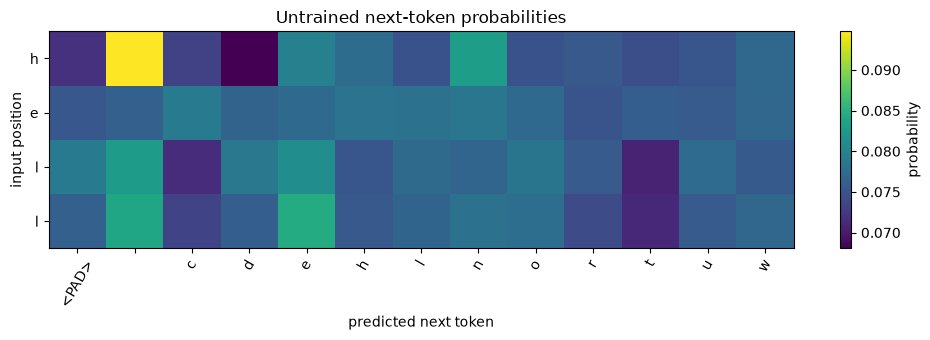

In [45]:
vocabulary_size = len(index_to_token)
embedding_dim = 6
hidden_dim = 8
embedding_matrix = generator.normal(scale=0.2, size=(vocabulary_size, embedding_dim))
rnn_weights_x = generator.normal(scale=0.2, size=(embedding_dim, hidden_dim))
rnn_weights_h = generator.normal(scale=0.2, size=(hidden_dim, hidden_dim))
rnn_bias = np.zeros(hidden_dim)
output_weights = generator.normal(scale=0.2, size=(hidden_dim, vocabulary_size))
output_bias = np.zeros(vocabulary_size)

input_vectors, _ = embedding_forward(input_tokens, embedding_matrix)
hidden_states, _ = rnn_forward(
    input_vectors, np.zeros((1, hidden_dim)),
    rnn_weights_x, rnn_weights_h, rnn_bias,
)
scores, _ = temporal_affine_forward(hidden_states, output_weights, output_bias)
pipeline_mask = np.ones_like(target_tokens, dtype=bool)
pipeline_loss, _ = temporal_softmax_loss(scores, target_tokens, pipeline_mask)
shifted_scores = scores - scores.max(axis=2, keepdims=True)
probabilities = np.exp(shifted_scores)
probabilities /= probabilities.sum(axis=2, keepdims=True)

assert input_vectors.shape == (1, 4, embedding_dim)
assert hidden_states.shape == (1, 4, hidden_dim)
assert scores.shape == (1, 4, vocabulary_size)
print(f"Untrained next-token loss: {pipeline_loss:.4f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
image = ax.imshow(probabilities[0], aspect="auto", cmap="viridis")
ax.set_yticks(range(input_tokens.shape[1]), labels=list(decoded_inputs))
ax.set_xticks(range(vocabulary_size), labels=index_to_token, rotation=60)
ax.set_xlabel("predicted next token")
ax.set_ylabel("input position")
ax.set_title("Untrained next-token probabilities")
fig.colorbar(image, ax=ax, label="probability")
plt.tight_layout()
plt.show()


## 8. Reflection

1. Why are token IDs not suitable as direct numerical input features?
2. What does each row of an embedding matrix represent?
3. Why must embedding gradients accumulate when a token repeats?
4. Why is there no ordinary gradient with respect to integer token IDs?
5. Why does the temporal affine layer share one weight matrix across time?
6. What shape does the temporal score tensor have, and what does each axis mean?
7. Why must padding positions have zero loss and zero score gradient?
8. How are language-model inputs aligned with their targets?

### Answers

1. Token IDs are arbitrary discrete labels, not measured quantities. Using them directly would create meaningless numerical ordering and distances—for example, token 6 is not inherently twice as meaningful as token 3.
2. Each row is a learned vector representation of one vocabulary token. Training adjusts it so that useful properties and relationships can be encoded across its dimensions.
3. Every occurrence of a token selects the same embedding row. Because that shared row influenced the loss through every occurrence, its gradient is the sum of all those contributions.
4. Token IDs are discrete row addresses, so an infinitesimal change to an ID is not meaningful. Gradients are instead calculated for the continuous embedding vectors selected by those IDs.
5. The meaning of an output vocabulary token should not depend on its sequence position. Sharing one projection also lets the model handle different sequence lengths without learning separate output parameters for every time step.
6. It has shape $(N,T,V)$: $N$ is the batch axis, $T$ is the time axis, and $V$ contains one score for each vocabulary token. Thus, $S_{n,t,v}$ scores token $v$ as the prediction at position $t$ in sequence $n$.
7. Padding is present only to create equal-sized arrays and is not real training data. Nonzero loss or gradients there would train the model to predict artificial padding positions and could distort parameter updates.
8. The inputs contain every token except the last, while the targets contain every token except the first. Consequently, the target at time $t$ is the token immediately following the input at time $t$.
